# 01 — Qualidade dos modelos via API

Avaliação dos 9 modelos LLM acessados via API nos 3 editais (BNDES, CVM, Petrobras).
Cada resposta foi julgada por dois avaliadores LLM (GPT e Claude Opus), com **árbitro
humano** resolvendo as 92 divergências.

**Saídas usadas pelos demais notebooks:**
- `avaliacao_final` por modelo
- Kappa GPT × Opus
- Métricas operacionais (latência, tokens, invocações)

In [2]:
# Setup comum
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150,
    'font.size': 10, 'axes.titleweight': 'bold', 'axes.titlesize': 12,
})

PALETA_PROVEDOR = {'anthropic': '#D97757', 'openai': '#10A37F', 'deepseek': '#4D6BFE'}
PALETA_AVALIADOR = {'gpt': '#10A37F', 'opus': '#D97757', 'humano': '#8E44AD'}
PALETA_TIPO = {'api': '#2E86AB', 'chat': '#E74C3C'}
CORES_NOTA = {0.0: '#E74C3C', 0.5: '#F39C12', 1.0: '#2ECC71'}

# Detecta a pasta data/ automaticamente — tenta vários caminhos
def find_data_dir():
    candidatos = [Path('.'), Path('data'), Path('../data'), Path('../../data'),
                  Path('./data'), Path('../../../data')]
    for p in candidatos:
        if (p / 'df_avaliacoes.xlsx').exists():
            return p.resolve()
    raise FileNotFoundError(
        'Não encontrei df_avaliacoes.xlsx. Coloque os 5 arquivos .xlsx '
        'em ./data/, ../data/, ou no mesmo diretório do notebook, ou edite '
        'a variável DATA manualmente abaixo.'
    )

DATA = find_data_dir()
INTER = DATA.parent / 'output' / 'intermediarios'
INTER.mkdir(parents=True, exist_ok=True)
print(f'DATA  = {DATA}')
print(f'INTER = {INTER}')

DATA  = /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/evals/tcc_analise
INTER = /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/evals/output/intermediarios


## 1. Carregamento

In [5]:
df_av  = pd.read_excel(DATA / 'df_avaliacoes.xlsx')
df_me  = pd.read_excel(DATA / 'df_metricas.xlsx')
df_div = pd.read_excel(DATA / 'divergentes_human_eval.xlsx')

print(f'df_avaliacoes : {df_av.shape}')
print(f'df_metricas   : {df_me.shape}')
print(f'df_divergentes: {df_div.shape}')
print(f'\nModelos: {sorted(df_av["modelo"].unique())}')
print(f'Editais: {sorted(df_av["edital"].unique())}')

df_avaliacoes : (1350, 12)
df_metricas   : (2700, 17)
df_divergentes: (92, 12)

Modelos: ['claude-haiku-4-5', 'claude-opus-4-7', 'claude-sonnet-4-6', 'deepseek-v4-flash', 'deepseek-v4-pro', 'gpt-4o-mini', 'gpt-5.4', 'gpt-5.4-mini', 'gpt-5.5']
Editais: ['bndes', 'cvm', 'petrobras']


## 2. Construção da avaliacao_final

Quando GPT e Opus convergem → usa o valor comum.
Quando divergem (92 casos) → usa o árbitro humano de `divergentes_human_eval.xlsx`.

In [6]:
df_div[['edital_h','modelo_h']] = df_div['pasta'].str.split('_', n=1, expand=True)
lookup = (df_div[['edital_h','modelo_h','id','Avaliação Humana','Modelo Correto']]
          .rename(columns={'edital_h':'edital','modelo_h':'modelo',
                           'Avaliação Humana':'avaliacao_humana',
                           'Modelo Correto':'modelo_correto'}))
df_av = df_av.merge(lookup, on=['edital','modelo','id'], how='left')

df_av['avaliacao_final'] = np.where(
    df_av['convergencia'],
    df_av['avaliacao_gpt'],
    df_av['avaliacao_humana']
)
df_av['nota_consenso'] = (df_av['avaliacao_gpt'] + df_av['avaliacao_opus']) / 2

print(f'Divergências aplicadas: {(~df_av["convergencia"]).sum()}')
print(f'Nulls em avaliacao_final: {df_av["avaliacao_final"].isna().sum()}')

Divergências aplicadas: 92
Nulls em avaliacao_final: 0


## 3. Distribuição das notas por avaliador

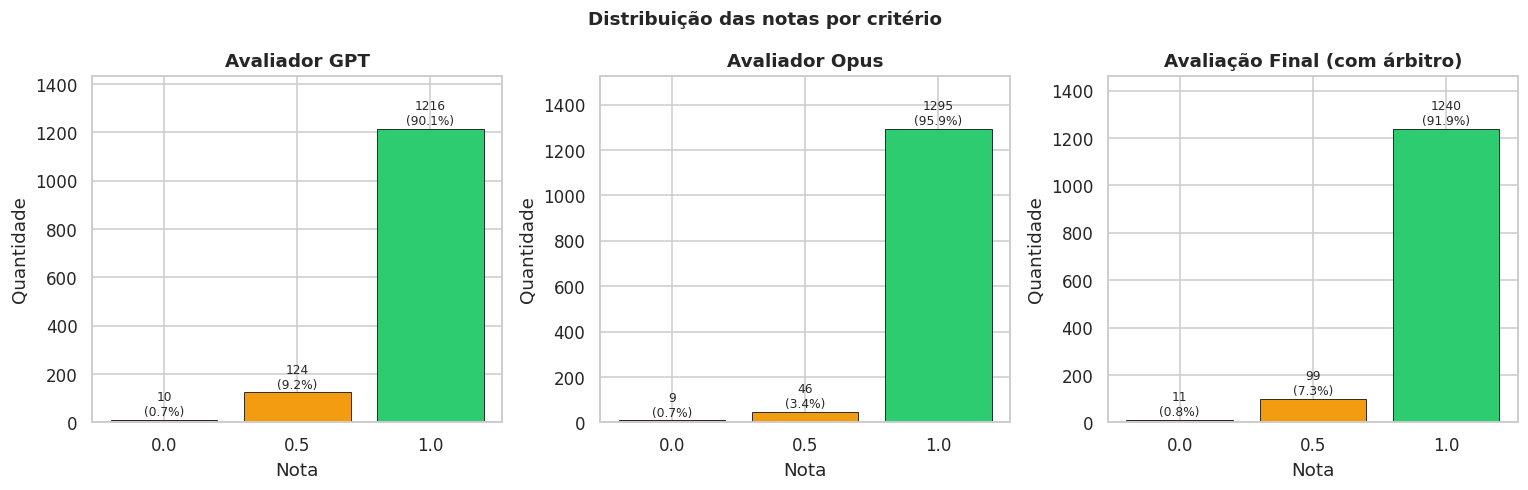

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, col, titulo in zip(axes,
        ['avaliacao_gpt', 'avaliacao_opus', 'avaliacao_final'],
        ['Avaliador GPT', 'Avaliador Opus', 'Avaliação Final (com árbitro)']):
    cnt = df_av[col].value_counts().sort_index()
    bars = ax.bar(cnt.index.astype(str), cnt.values,
                  color=[CORES_NOTA[k] for k in cnt.index],
                  edgecolor='black', linewidth=0.5)
    ax.set_title(titulo)
    ax.set_xlabel('Nota'); ax.set_ylabel('Quantidade')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+5,
                f'{int(h)}\n({h/len(df_av)*100:.1f}%)',
                ha='center', va='bottom', fontsize=8)
    ax.set_ylim(0, cnt.max() * 1.18)
plt.suptitle('Distribuição das notas por critério', fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Convergência GPT × Opus e Cohen's Kappa

In [8]:
from sklearn.metrics import cohen_kappa_score
conv = df_av['convergencia'].mean()
gpt_int  = (df_av['avaliacao_gpt']  * 2).astype(int)
opus_int = (df_av['avaliacao_opus'] * 2).astype(int)
kappa = cohen_kappa_score(gpt_int, opus_int)
print(f'Convergência global: {conv:.1%} ({int(conv*len(df_av))} de {len(df_av)})')
print(f"Cohen's Kappa:      {kappa:.3f}")
print('Interpretação: <0.20 fraca | 0.21-0.40 razoável | 0.41-0.60 moderada')
print('               0.61-0.80 substancial | >0.80 quase perfeita')

Convergência global: 93.2% (1258 de 1350)
Cohen's Kappa:      0.487
Interpretação: <0.20 fraca | 0.21-0.40 razoável | 0.41-0.60 moderada
               0.61-0.80 substancial | >0.80 quase perfeita


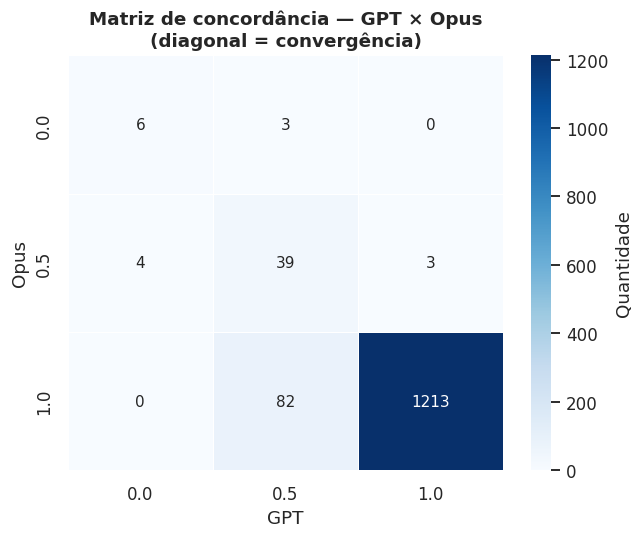

In [9]:
matriz = pd.crosstab(df_av['avaliacao_opus'], df_av['avaliacao_gpt'],
                    rownames=['Opus'], colnames=['GPT'])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            cbar_kws={'label':'Quantidade'}, linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Matriz de concordância — GPT × Opus\n(diagonal = convergência)')
plt.tight_layout(); plt.show()

## 5. Direção das divergências: em quem o humano confiou?

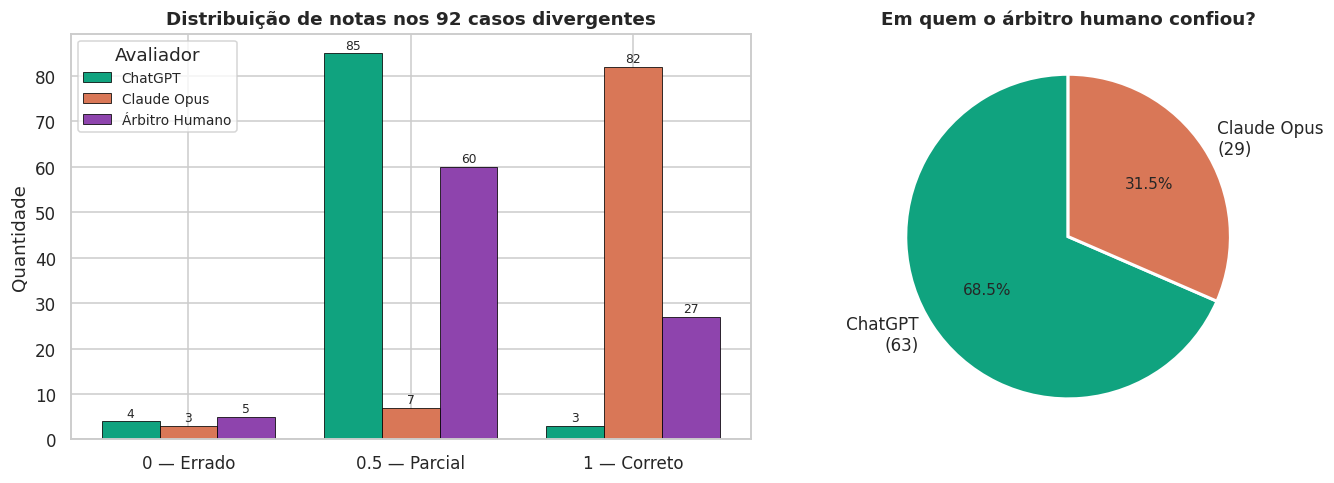


Humano concordou com ChatGPT:    63
Humano concordou com Claude Opus: 29


In [10]:
df_dv = df_av[~df_av['convergencia']].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

notas = [0.0, 0.5, 1.0]; x = np.arange(len(notas)); w = 0.26
cols_av = {
    'ChatGPT':       ('avaliacao_gpt',   PALETA_AVALIADOR['gpt']),
    'Claude Opus':   ('avaliacao_opus',  PALETA_AVALIADOR['opus']),
    'Árbitro Humano':('avaliacao_final', PALETA_AVALIADOR['humano']),
}
for i, (label, (col, cor)) in enumerate(cols_av.items()):
    cnt = df_dv[col].value_counts().reindex(notas, fill_value=0)
    bars = axes[0].bar(x + (i-1)*w, cnt.values, w, label=label, color=cor,
                       edgecolor='black', linewidth=0.5)
    for bar, v in zip(bars, cnt.values):
        if v > 0:
            axes[0].text(bar.get_x()+bar.get_width()/2, v+0.3, str(v),
                         ha='center', va='bottom', fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(['0 — Errado','0.5 — Parcial','1 — Correto'])
axes[0].set_ylabel('Quantidade')
axes[0].set_title('Distribuição de notas nos 92 casos divergentes')
axes[0].legend(title='Avaliador', fontsize=9)

razao = df_dv['modelo_correto'].value_counts()
NOMES_JUIZ = {'gpt':'ChatGPT', 'opus':'Claude Opus'}
labels_pie = [f'{NOMES_JUIZ.get(k,k)}\n({v})' for k,v in razao.items()]
cores_r = [PALETA_AVALIADOR.get(k,'#BDC3C7') for k in razao.index]
axes[1].pie(razao.values, labels=labels_pie, colors=cores_r,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Em quem o árbitro humano confiou?')

plt.tight_layout(); plt.show()
print(f'\nHumano concordou com ChatGPT:    {razao.get("gpt", 0)}')
print(f'Humano concordou com Claude Opus: {razao.get("opus", 0)}')

## 6. Ranking dos modelos pela avaliacao_final

In [11]:
ranking = (df_av.groupby(['modelo','provedor']).agg(
        avaliacao_final=('avaliacao_final','mean'),
        nota_consenso=('nota_consenso','mean'),
        convergencia=('convergencia','mean'),
        n_divergencias=('convergencia', lambda x: (~x).sum()),
        n=('id','count'),
    ).reset_index().sort_values('avaliacao_final', ascending=False).reset_index(drop=True))
ranking.index += 1; ranking.index.name = 'rank'
ranking.round(4)

,modelo,provedor,avaliacao_final,nota_consenso,convergencia,n_divergencias,n
rank,,,,,,,
1,gpt-5.5,openai,0.9967,0.9917,0.9667,5,150
2,claude-opus-4-7,anthropic,0.9767,0.9833,0.9467,8,150
3,claude-sonnet-4-6,anthropic,0.9733,0.9800,0.9467,8,150
4,deepseek-v4-flash,deepseek,0.9700,0.9767,0.9467,8,150
5,deepseek-v4-pro,deepseek,0.9633,0.9650,0.9133,13,150
6,gpt-5.4,openai,0.9633,0.9633,0.9867,2,150
7,claude-haiku-4-5,anthropic,0.9367,0.9550,0.8867,17,150
8,gpt-4o-mini,openai,0.9100,0.9250,0.9000,15,150
9,gpt-5.4-mini,openai,0.9067,0.9133,0.8933,16,150


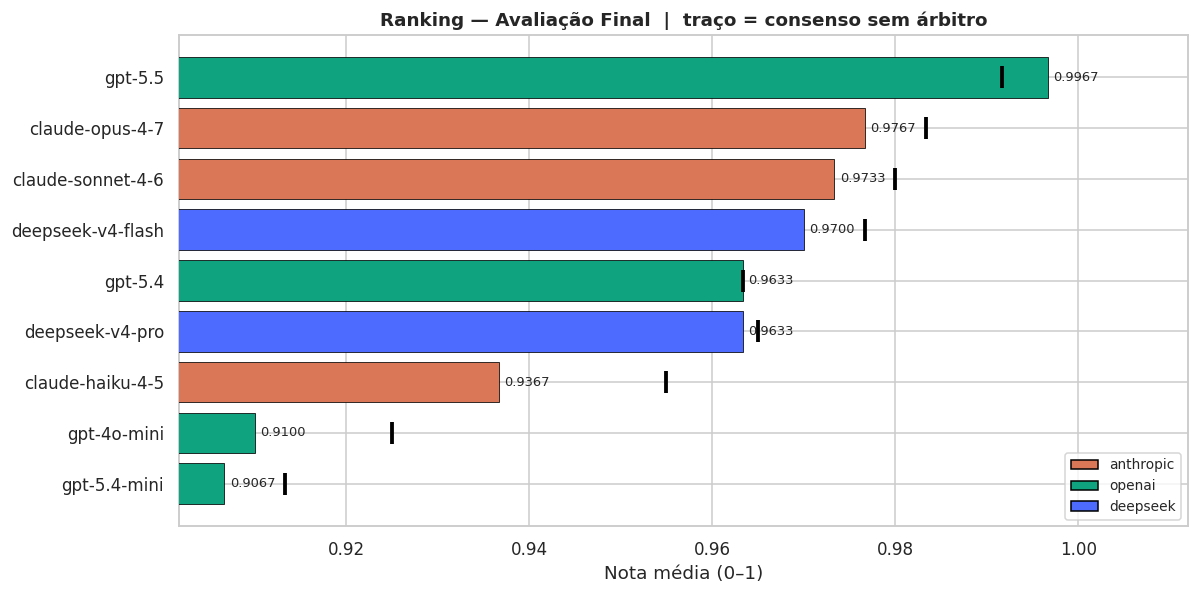

In [12]:
fig, ax = plt.subplots(figsize=(11, 5.5))
df_plot = ranking.sort_values('avaliacao_final', ascending=True)
cores = [PALETA_PROVEDOR[p] for p in df_plot['provedor']]
bars = ax.barh(df_plot['modelo'], df_plot['avaliacao_final'],
               color=cores, edgecolor='black', linewidth=0.5,
               label='Avaliação Final', zorder=3)
ax.scatter(df_plot['nota_consenso'], df_plot['modelo'],
           color='black', marker='|', s=200, linewidths=2.5, zorder=4,
           label='Consenso (sem árbitro)')
xmin = min(df_plot[['avaliacao_final','nota_consenso']].min()) - 0.005
ax.set_xlim(xmin, 1.012)
ax.set_xlabel('Nota média (0–1)')
ax.set_title('Ranking — Avaliação Final  |  traço = consenso sem árbitro')
for bar, val in zip(bars, df_plot['avaliacao_final']):
    ax.text(val + 0.0006, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8.5)
legend = [mpatches.Patch(facecolor=c, edgecolor='black', label=p)
          for p, c in PALETA_PROVEDOR.items()]
ax.legend(handles=legend, loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

## 7. Heatmaps: modelo × edital e modelo × categoria

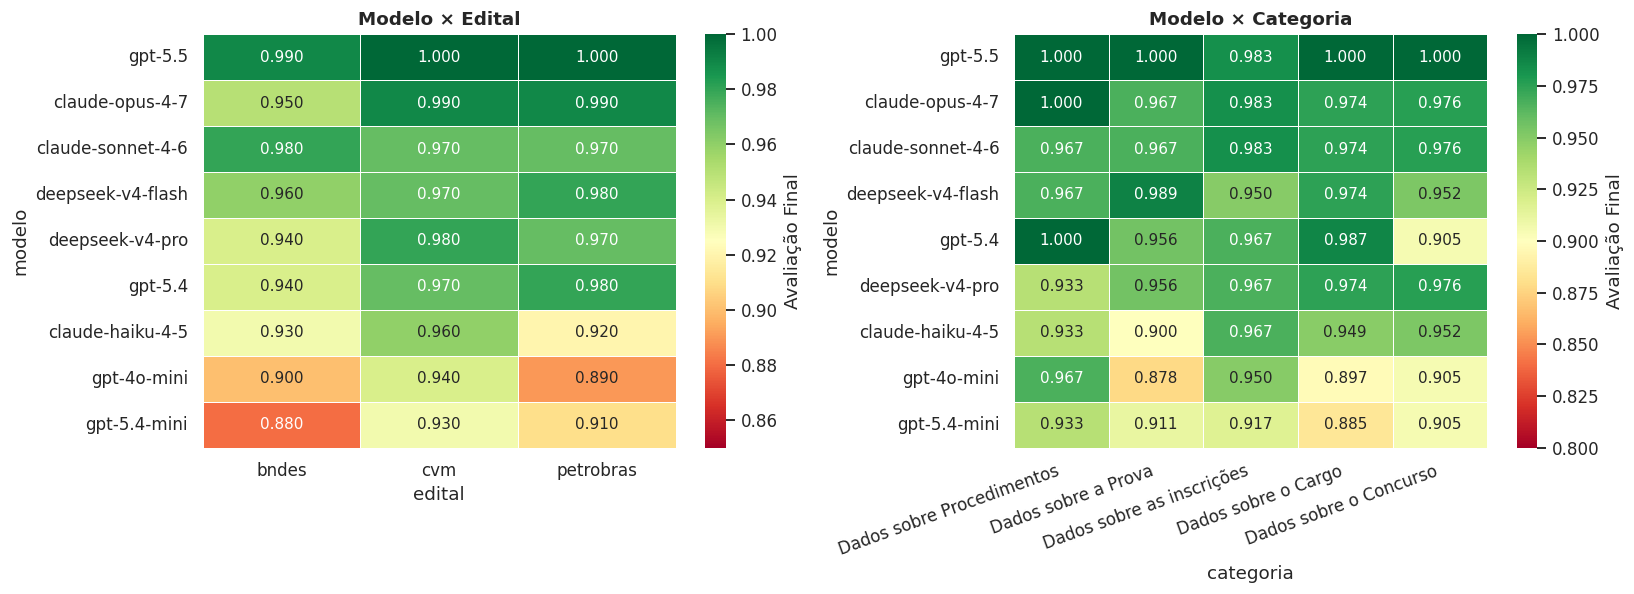

In [13]:
heat_ed = df_av.groupby(['modelo','edital'])['avaliacao_final'].mean().unstack()
heat_ed = heat_ed.loc[heat_ed.mean(axis=1).sort_values(ascending=False).index]

heat_cat = df_av.groupby(['modelo','categoria'])['avaliacao_final'].mean().unstack()
heat_cat = heat_cat.loc[heat_cat.mean(axis=1).sort_values(ascending=False).index]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(heat_ed, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.85, vmax=1.0,
            cbar_kws={'label':'Avaliação Final'}, linewidths=0.5, ax=axes[0])
axes[0].set_title('Modelo × Edital')
sns.heatmap(heat_cat, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.80, vmax=1.0,
            cbar_kws={'label':'Avaliação Final'}, linewidths=0.5, ax=axes[1])
axes[1].set_title('Modelo × Categoria')
plt.setp(axes[1].get_xticklabels(), rotation=20, ha='right')
plt.tight_layout(); plt.show()

## 8. Métricas operacionais (latência, tokens, invocações)

In [14]:
df_op = df_me[df_me['avaliador'] == 'gpt'].copy()
print(f'Amostra operacional: {len(df_op)} linhas (uma por pergunta×modelo)')

Amostra operacional: 1350 linhas (uma por pergunta×modelo)


/tmp/ipykernel_82320/195895753.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot([df_op[df_op['modelo']==m]['latencia_s'].values for m in ordem_lat],


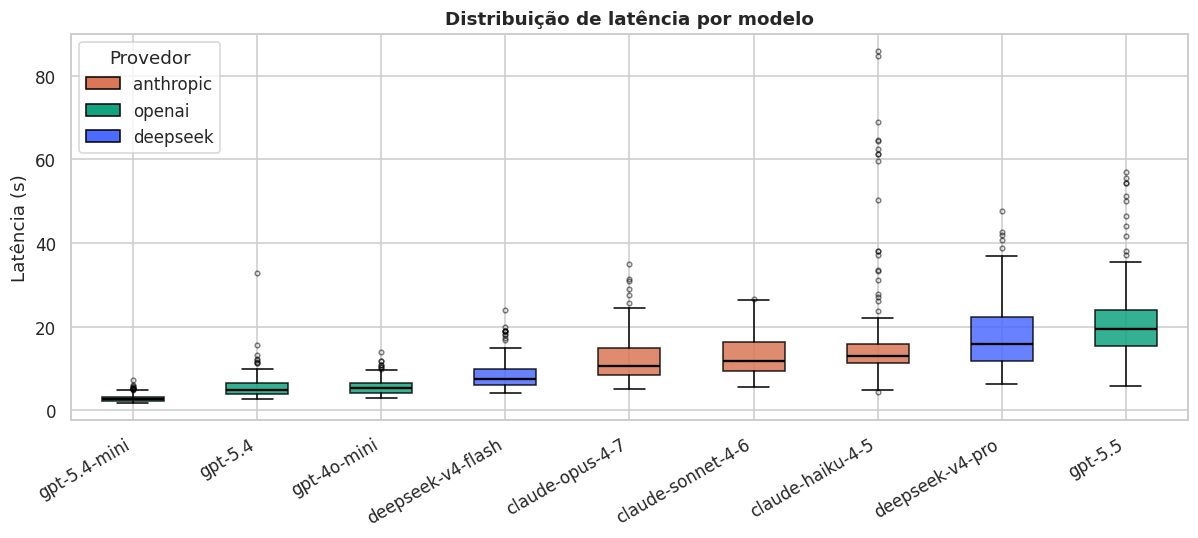

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
ordem_lat = df_op.groupby('modelo')['latencia_s'].median().sort_values().index
cores_box = [PALETA_PROVEDOR[df_op[df_op['modelo']==m]['provedor'].iloc[0]] for m in ordem_lat]
box = ax.boxplot([df_op[df_op['modelo']==m]['latencia_s'].values for m in ordem_lat],
                 labels=ordem_lat, patch_artist=True, showfliers=True,
                 medianprops={'color':'black','linewidth':1.5},
                 flierprops={'marker':'o','markersize':3,'alpha':0.5})
for patch, color in zip(box['boxes'], cores_box):
    patch.set_facecolor(color); patch.set_edgecolor('black'); patch.set_alpha(0.85)
ax.set_ylabel('Latência (s)')
ax.set_title('Distribuição de latência por modelo')
ax.tick_params(axis='x', rotation=30)
plt.setp(ax.get_xticklabels(), ha='right')
legend = [mpatches.Patch(facecolor=c, edgecolor='black', label=p)
          for p,c in PALETA_PROVEDOR.items()]
ax.legend(handles=legend, title='Provedor', loc='upper left')
plt.tight_layout(); plt.show()

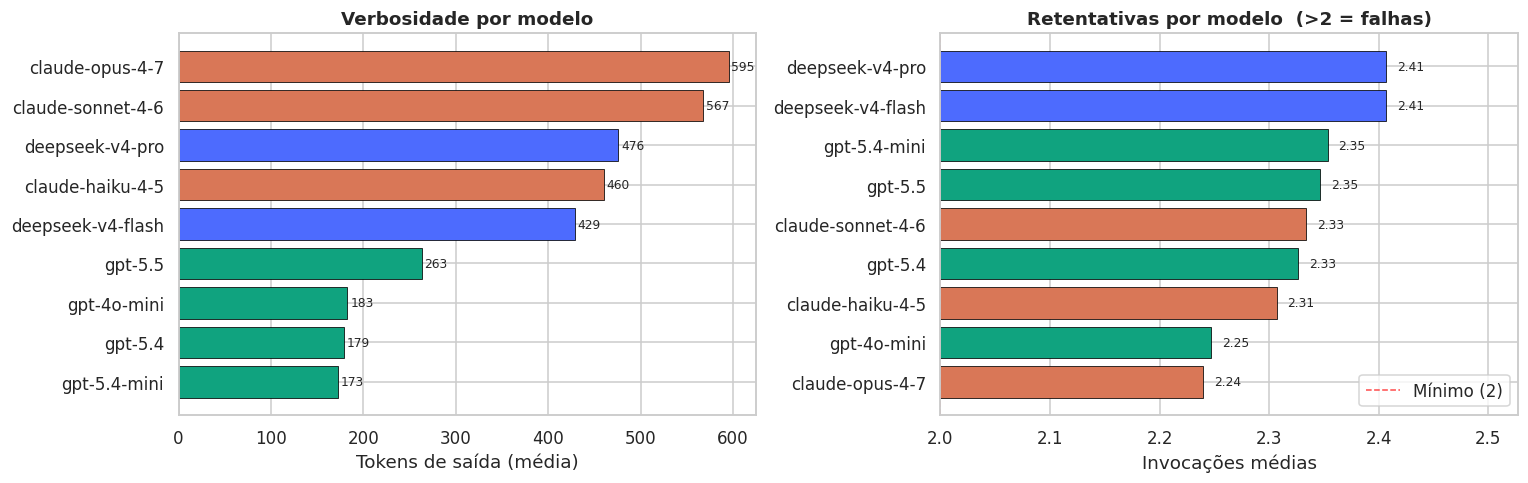

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
out_avg = (df_op.groupby(['modelo','provedor'])['output_tokens']
           .mean().reset_index().sort_values('output_tokens'))
cores_t = [PALETA_PROVEDOR[p] for p in out_avg['provedor']]
axes[0].barh(out_avg['modelo'], out_avg['output_tokens'],
             color=cores_t, edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Tokens de saída (média)')
axes[0].set_title('Verbosidade por modelo')
for bar, v in zip(axes[0].patches, out_avg['output_tokens']):
    axes[0].text(v + 3, bar.get_y() + bar.get_height()/2,
                 f'{v:.0f}', va='center', fontsize=8)

inv_mod = df_op.groupby('modelo')['n_invocacoes'].mean().sort_values()
cores_inv = [PALETA_PROVEDOR[df_op[df_op['modelo']==m]['provedor'].iloc[0]] for m in inv_mod.index]
axes[1].barh(inv_mod.index, inv_mod.values,
             color=cores_inv, edgecolor='black', linewidth=0.5)
axes[1].axvline(2, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Mínimo (2)')
axes[1].set_xlabel('Invocações médias')
axes[1].set_title('Retentativas por modelo  (>2 = falhas)')
axes[1].set_xlim(2, inv_mod.max() * 1.05)
axes[1].legend(loc='lower right')
for i, v in enumerate(inv_mod.values):
    axes[1].text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=8)
plt.tight_layout(); plt.show()

## 9. Trade-off Qualidade × Latência

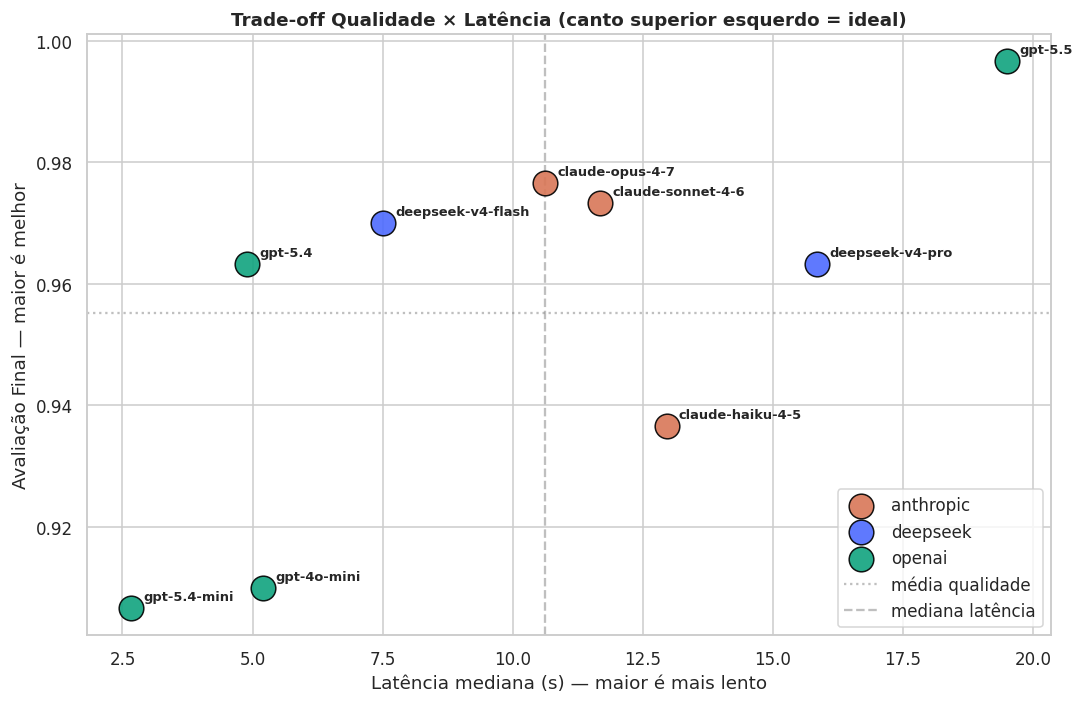

In [17]:
qual = df_av.groupby('modelo')['avaliacao_final'].mean().rename('nota')
lat  = df_op.groupby('modelo')['latencia_s'].median().rename('latencia')
prov = df_av.groupby('modelo')['provedor'].first()
trade = pd.concat([qual, lat, prov], axis=1).reset_index()

fig, ax = plt.subplots(figsize=(10, 6.5))
for pv, grupo in trade.groupby('provedor'):
    ax.scatter(grupo['latencia'], grupo['nota'],
               color=PALETA_PROVEDOR[pv], s=260, edgecolor='black',
               linewidth=1.0, label=pv, alpha=0.9, zorder=3)
for _, r in trade.iterrows():
    ax.annotate(r['modelo'], (r['latencia'], r['nota']),
                xytext=(8, 5), textcoords='offset points',
                fontsize=8.5, fontweight='bold')
ax.axhline(trade['nota'].mean(), color='gray', linestyle=':', alpha=0.5,
           label='média qualidade')
ax.axvline(trade['latencia'].median(), color='gray', linestyle='--', alpha=0.5,
           label='mediana latência')
ax.set_xlabel('Latência mediana (s) — maior é mais lento')
ax.set_ylabel('Avaliação Final — maior é melhor')
ax.set_title('Trade-off Qualidade × Latência (canto superior esquerdo = ideal)')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

## 10. Resumo: o que ficou para os demais notebooks

A partir deste notebook:
- `df_av` carrega a coluna `avaliacao_final` (nota final consolidada)
- Os 9 modelos API têm avaliação por correção pura (rubric do GPT/Opus + humano)
- Os modelos têm **TODOS** avaliação ≥ 0.91 — ou seja, em correção pura, são quase indistinguíveis

A análise do estudo 3 (concisão) e do notebook de integração vai mostrar que
**a diferença real entre os modelos não está na correção, está na concisão**.